In [ ]:
# Code used to genereate the figures shown in Figure 3

In [ ]:
#Figure 3A -  RMSD(Root Mean Square Deviation)

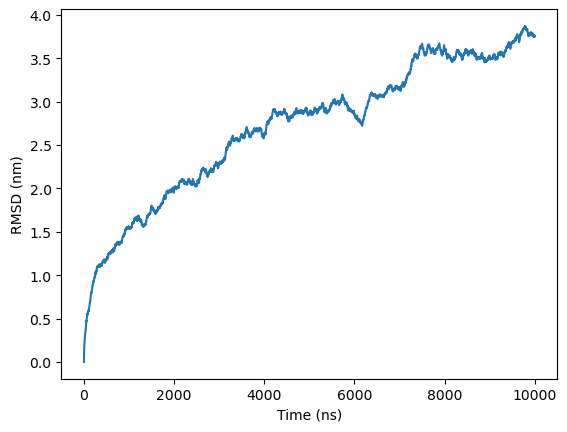

In [1]:
import matplotlib.pyplot as plt
with open(r"D:\dsup_plot\rmsd.xvg") as f:
    data = []
    for line in f:
        if not line.startswith(("#","@")):
            t, rms = map(float, line.split())
            data.append((t, rms))

time, rmsd = zip(*data)
plt.plot(time, rmsd)
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.show()

In [ ]:
#Figure 3B - Radius of Gyration

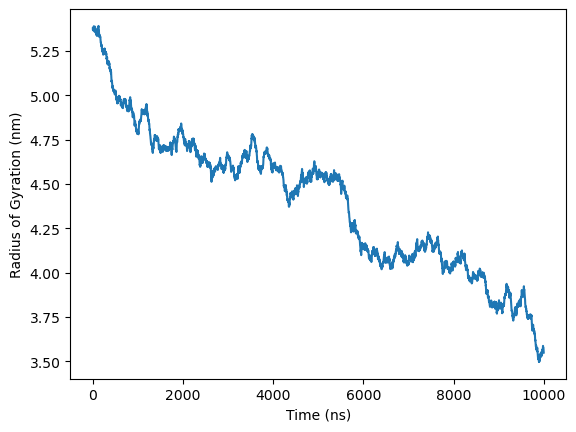

In [2]:
import matplotlib.pyplot as plt

data = []
with open(r"D:\dsup_plot\gyrate.xvg") as f:
    for line in f:
        if not line.startswith(("#","@")):
            parts = line.split()
            t = float(parts[0])
            rg = float(parts[1])  # take the first data column after time
            data.append((t, rg))

time, rg = zip(*data)
plt.plot(time, rg)
plt.xlabel("Time (ns)")
plt.ylabel("Radius of Gyration (nm)")
plt.show()

In [ ]:
# Figure 3C - RMSF (Root Mean Square Fluctuation)

Mean RMSF: 1.3536775280898878
Max RMSF: 3.3039
Min RMSF: 0.5895

Highly flexible residues (IDR candidates):
[  1   2   3 121 122 123 124 125 126 127 349 350 355 357 358 359 360 361
 362 363 364 365 366 367 368 369 370 371 372 373 374 375 376]

Low flexibility residues (possible structural cores):
[177 178 179 180 181 182 186 188 189 190 191 192 193 194 196 198 199 200
 203]


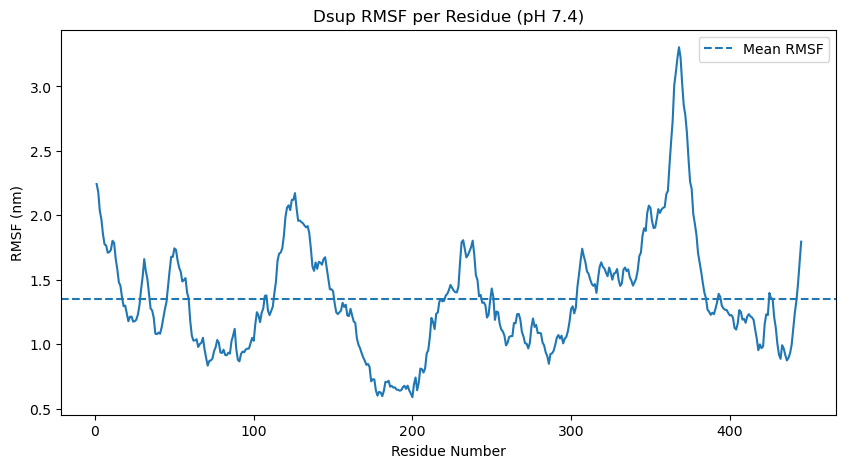

In [3]:
import matplotlib.pyplot as plt
import numpy as np

residue = []
rmsf = []

with open(r"D:\dsup_plot\rmsf_residue.xvg") as f:
    for line in f:
        if not line.startswith(("#", "@")):
            parts = line.split()
            residue.append(int(float(parts[0])))
            rmsf.append(float(parts[1]))

residue = np.array(residue)
rmsf = np.array(rmsf)

# ---- Basic statistics ----
mean_rmsf = np.mean(rmsf)
max_rmsf = np.max(rmsf)
min_rmsf = np.min(rmsf)

print("Mean RMSF:", mean_rmsf)
print("Max RMSF:", max_rmsf)
print("Min RMSF:", min_rmsf)

# ---- Identify flexible regions ----
threshold_high = mean_rmsf * 1.5
threshold_low = mean_rmsf * 0.5

high_flex = residue[rmsf > threshold_high]
low_flex = residue[rmsf < threshold_low]

print("\nHighly flexible residues (IDR candidates):")
print(high_flex)

print("\nLow flexibility residues (possible structural cores):")
print(low_flex)

# ---- Plot ----
plt.figure(figsize=(10,5))
plt.plot(residue, rmsf)

plt.axhline(mean_rmsf, linestyle="--", label="Mean RMSF")
plt.xlabel("Residue Number")
plt.ylabel("RMSF (nm)")
plt.title("Dsup RMSF per Residue (pH 7.4)")
plt.legend()
plt.show()

In [ ]:
#Figure 3D - Energy stabilization

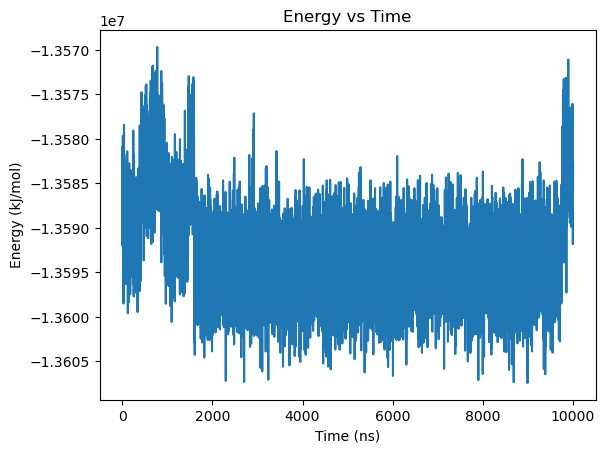

In [4]:
import matplotlib.pyplot as plt

time = []
energy = []

with open(r"D:\dsup_plot\energy.xvg") as f:
    for line in f:
        if not line.startswith(("#","@")):
            parts = line.split()
            time.append(float(parts[0]))
            energy.append(float(parts[1]))  # first energy column

plt.plot(time, energy)
plt.xlabel("Time (ns)")
plt.ylabel("Energy (kJ/mol)")
plt.title("Energy vs Time")
plt.show()

In [ ]:
#Figure 3E - Solvent Accessible Surface

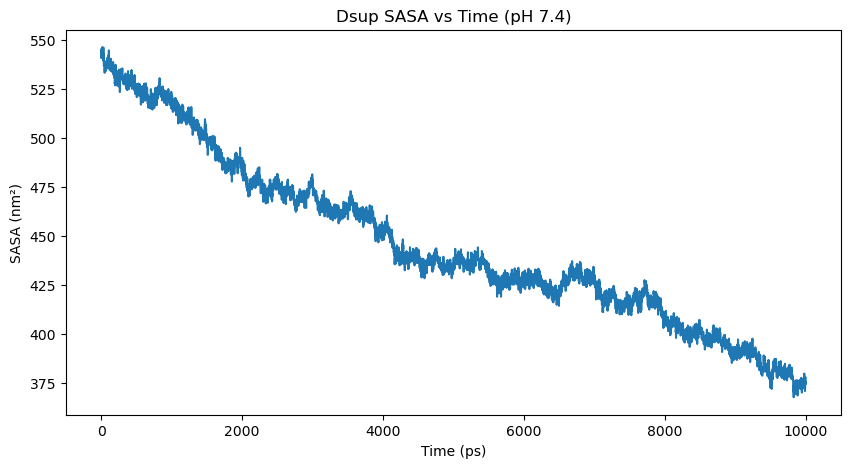

In [5]:
import matplotlib.pyplot as plt

time = []
sasa = []

with open(r"D:\dsup_plot\sasa.xvg") as f:
    for line in f:
        if not line.startswith(("#", "@")):
            parts = line.split()
            time.append(float(parts[0]))
            sasa.append(float(parts[1]))

plt.figure(figsize=(10,5))
plt.plot(time, sasa)

plt.xlabel("Time (ps)")
plt.ylabel("SASA (nm²)")
plt.title("Dsup SASA vs Time (pH 7.4)")
plt.show()

In [ ]:
#Figure 3F - Hydrogen bonds for protein protein and Protein water

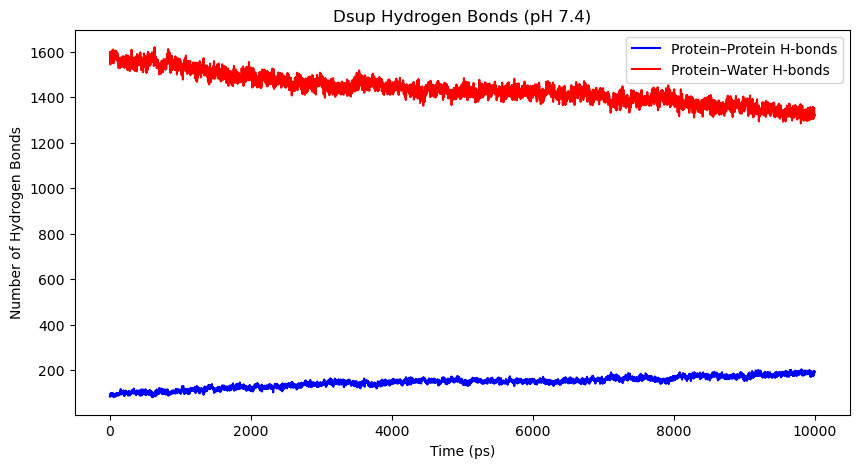

In [6]:
import matplotlib.pyplot as plt

def read_xvg(file):
    x = []
    y = []
    with open(file) as f:
        for line in f:
            if not line.startswith(("#", "@")):
                parts = line.split()
                x.append(float(parts[0]))
                y.append(float(parts[1]))
    return x, y


time_pp, hb_pp = read_xvg(r"D:\dsup_plot\hbonds.xvg")
time_pw, hb_pw = read_xvg(r"D:\dsup_plot\hbonds_pw.xvg")


plt.figure(figsize=(10,5))
plt.plot(time_pp, hb_pp, label="Protein–Protein H-bonds", color="blue")
plt.plot(time_pw, hb_pw, label="Protein–Water H-bonds", color="red")

plt.xlabel("Time (ps)")
plt.ylabel("Number of Hydrogen Bonds")
plt.title("Dsup Hydrogen Bonds (pH 7.4)")
plt.legend()
plt.show()